<a href="https://colab.research.google.com/github/pabanib/Cursos/blob/master/regresion_logistica_conceptual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión logística: entender el modelo experimentando


**Cuaderno conceptual · scikit-learn · clasificación binaria**

Trabajaremos con datos simulados para observar qué hace el modelo en condiciones que podemos controlar.

**Al terminar vas a poder:**

- Explicar por qué una recta no garantiza probabilidades válidas.
- Relacionar la combinación lineal, la sigmoide y la probabilidad.
- Interpretar el signo de los coeficientes y el papel del intercepto.
- Explicar, intuitivamente, qué busca el modelo al ajustarse.
- Distinguir entre estimar una probabilidad y decidir una clase.
- Reconocer la frontera lineal de la regresión logística.




## Preparación

Usaremos NumPy, pandas, Matplotlib y scikit-learn. Los datos se generan aquí: no hace falta descargar archivos ni acceder a cuentas.

Si falta alguna biblioteca, ejecutá la siguiente celda quitando el `#`. Este cuaderno utiliza **scikit-learn 1.8 o posterior**. Después de instalar o actualizar bibliotecas, reiniciá el kernel o entorno de ejecución y ejecutá todo desde el principio.


In [ ]:
# %pip install "scikit-learn>=1.8" numpy pandas matplotlib


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from IPython.display import display
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
})
AZUL, ROSA, GRIS = "#2563EB", "#DB2777", "#64748B"

def sigmoide(z):
    return 1 / (1 + np.exp(-np.asarray(z)))

print("scikit-learn:", sklearn.__version__)


scikit-learn: 1.8.0


## 1. ¿Qué queremos predecir?

Imaginemos que conocemos las horas de estudio de un grupo de estudiantes y queremos estimar la probabilidad de aprobar.

- **Variable explicativa:** horas de estudio.
- **Variable respuesta:** `aprobo`, con `0 = no aprobó` y `1 = aprobó`.
- **Clase positiva:** la categoría codificada como 1; aquí, “aprobó”. “Positiva” es una convención, no una valoración.

Cada estudiante tiene un resultado observado, 0 o 1. El modelo, en cambio, estima una **probabilidad**: por ejemplo, 0,70.

Una variable numérica discreta no implica necesariamente clasificación: un conteo también puede ser un objetivo de regresión. Aquí clasificamos porque el objetivo representa dos categorías.


,horas,aprobo
0,7.74,1
1,4.39,0
2,8.59,1
3,6.97,1
4,0.94,0


aprobo
0    161
1    139
Name: Cantidad, dtype: int64

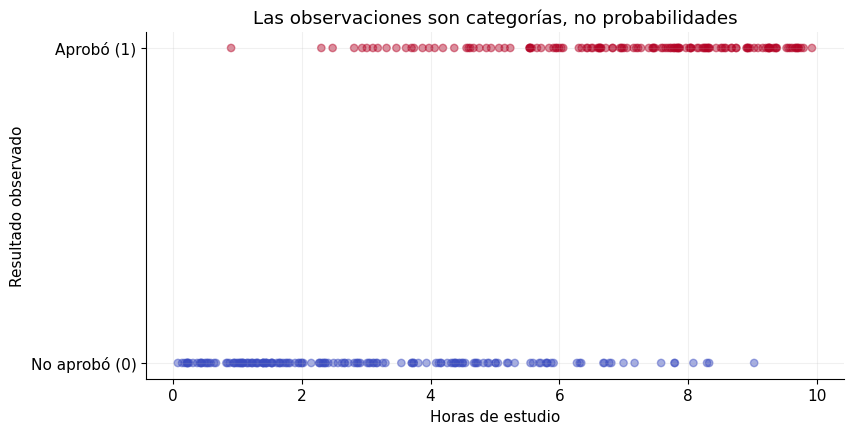

In [ ]:
# Ejemplo simulado: no representa un estudio real sobre aprendizaje.
rng = np.random.default_rng(42)
horas = rng.uniform(0, 10, size=300)

# Esta es la regla que usamos para crear los datos; el modelo no la conoce.
p_generadora = sigmoide(-4 + 0.8 * horas)
aprobo = rng.binomial(n=1, p=p_generadora)

datos = pd.DataFrame({"horas": horas, "aprobo": aprobo})
display(datos.head().round(2))
display(datos["aprobo"].value_counts().sort_index().rename("Cantidad"))

fig, ax = plt.subplots()
ax.scatter(datos["horas"], datos["aprobo"], c=datos["aprobo"],
           cmap="coolwarm", alpha=0.45, s=28)
ax.set(xlabel="Horas de estudio", ylabel="Resultado observado",
       yticks=[0, 1], yticklabels=["No aprobó (0)", "Aprobó (1)"],
       title="Las observaciones son categorías, no probabilidades")
plt.show()


**Para observar:** hay estudiantes con pocas horas que aprueban y estudiantes con muchas horas que no aprueban. La relación es probabilística, no una regla infalible.

Aunque generamos los resultados usando una probabilidad, solo entregaremos al modelo las horas y los resultados observados. La probabilidad generadora sirve como referencia didáctica.


In [ ]:
X = datos[["horas"]]
y = datos["aprobo"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(f"Entrenamiento: {len(X_train)} estudiantes")
print(f"Prueba: {len(X_test)} estudiantes")


Entrenamiento: 210 estudiantes
Prueba: 90 estudiantes


Separamos los datos antes del ajuste. El modelo aprende con entrenamiento y observamos su desempeño con estudiantes que no usó para aprender.

`stratify=y` conserva aproximadamente la proporción de cada clase en ambas partes. No elegiremos parámetros ni umbrales óptimos usando el conjunto de prueba: aquí compararemos umbrales prefijados con fines ilustrativos.


## 2. ¿Por qué no alcanza con una regresión lineal?

Podemos ajustar una regresión lineal a una respuesta 0/1. La dificultad es que una recta no está limitada al intervalo [0, 1]: algunas de sus predicciones pueden ser negativas o mayores que uno.

Ajustemos ambos modelos al **mismo conjunto de entrenamiento**.

**Detalle de la implementación:** usamos `C=np.inf` para que el ajuste corresponda a la máxima verosimilitud. Esto quiere decir que el modelo no recibe regularización (tema que no veremos en el curso). Lo dejamos fijo durante todo el cuaderno.


c:\Users\Pablo\miniconda3\envs\main\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


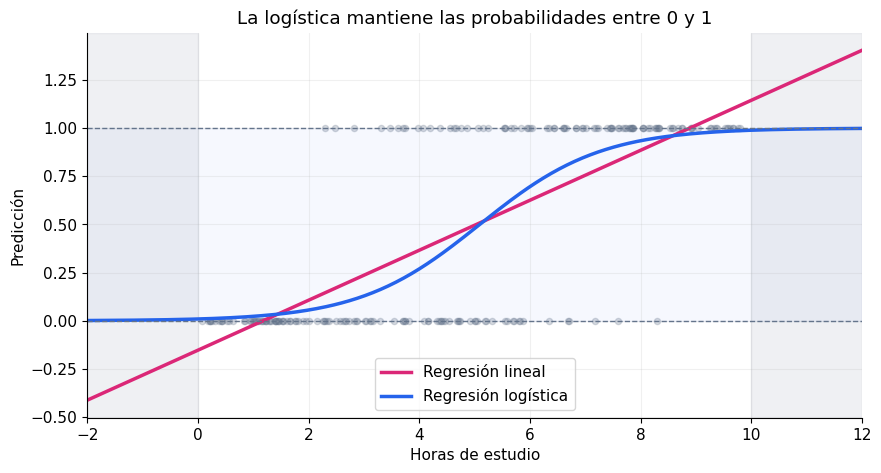

,Modelo,Mínimo en la rejilla,Máximo en la rejilla
0,Lineal,-0.412,1.404
1,Logística,0.002,0.998


In [ ]:
lineal = LinearRegression().fit(X_train, y_train)
logistica = LogisticRegression(C=np.inf, max_iter=1000, tol=1e-9)
logistica.fit(X_train, y_train)

# Las columnas de predict_proba siguen el orden de classes_.
col_positiva = list(logistica.classes_).index(1)
rejilla = pd.DataFrame({"horas": np.linspace(-2, 12, 400)})
pred_lineal = lineal.predict(rejilla)
pred_logistica = logistica.predict_proba(rejilla)[:, col_positiva]

fig, ax = plt.subplots(figsize=(10, 5))
ax.axhspan(0, 1, color=AZUL, alpha=0.04)
ax.axvspan(-2, 0, color=GRIS, alpha=0.1)
ax.axvspan(10, 12, color=GRIS, alpha=0.1)
ax.scatter(X_train["horas"], y_train, color=GRIS, alpha=0.25, s=20)
ax.plot(rejilla["horas"], pred_lineal, color=ROSA, lw=2.5,
        label="Regresión lineal")
ax.plot(rejilla["horas"], pred_logistica, color=AZUL, lw=2.5,
        label="Regresión logística")
ax.axhline(0, color=GRIS, ls="--", lw=1)
ax.axhline(1, color=GRIS, ls="--", lw=1)
ax.set(xlabel="Horas de estudio", ylabel="Predicción",
       title="La logística mantiene las probabilidades entre 0 y 1",
       xlim=(-2, 12))
ax.legend()
plt.show()

display(pd.DataFrame({
    "Modelo": ["Lineal", "Logística"],
    "Mínimo en la rejilla": [pred_lineal.min(), pred_logistica.min()],
    "Máximo en la rejilla": [pred_lineal.max(), pred_logistica.max()]
}).round(3))


**Conclusión.** La regresión lineal puede servir para construir una regla de clasificación, pero sus salidas no siempre son probabilidades válidas. La regresión logística incorpora esa restricción en su fórmula.

Las bandas grises muestran valores fuera del rango usado para generar los datos. Las horas negativas solo ilustran el comportamiento matemático de las funciones; no tienen interpretación real. Que la logística permanezca entre 0 y 1 tampoco garantiza que sus predicciones fuera del rango observado sean correctas.


## 3. ¿Cómo se transforma una recta en una probabilidad?

La regresión logística tiene dos componentes:

### Paso 1: calcular un puntaje

$$z=\beta_0+\beta_1x$$

El puntaje puede tomar cualquier valor real.

### Paso 2: aplicar la función sigmoide

$$p(y=1\mid x)=\sigma(z)=\frac{1}{1+e^{-z}}$$

- Si $z=0$, la probabilidad es 0,5.
- Si $z>0$, la probabilidad es mayor que 0,5.
- Si $z<0$, la probabilidad es menor que 0,5.

La sigmoide convierte el puntaje en una probabilidad. Todavía no hemos decidido una clase.


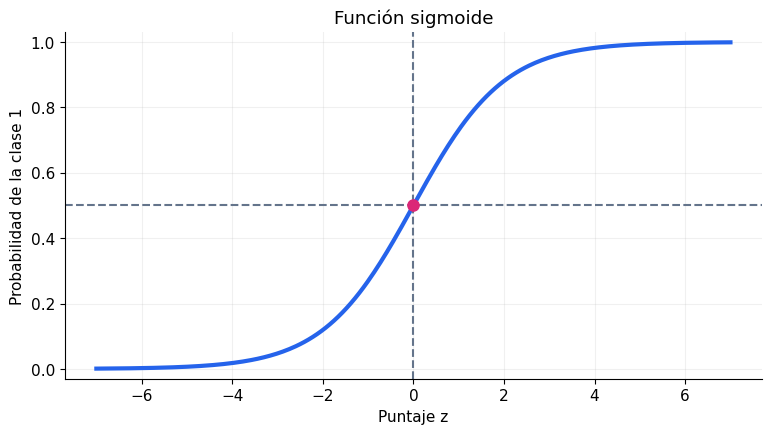

,z,sigmoide(z)
0,-4,0.018
1,-2,0.119
2,0,0.500
3,2,0.881
4,4,0.982


In [ ]:
z = np.linspace(-7, 7, 300)
fig, ax = plt.subplots()
ax.plot(z, sigmoide(z), color=AZUL, lw=3)
ax.scatter([0], [0.5], color=ROSA, s=65, zorder=3)
ax.axvline(0, color=GRIS, ls="--")
ax.axhline(0.5, color=GRIS, ls="--")
ax.set(xlabel="Puntaje z", ylabel="Probabilidad de la clase 1",
       title="Función sigmoide", ylim=(-0.03, 1.03))
plt.show()

display(pd.DataFrame({
    "z": [-4, -2, 0, 2, 4],
    "sigmoide(z)": sigmoide([-4, -2, 0, 2, 4])
}).round(3))


### Experimento: cambiar los coeficientes

Primero variamos el intercepto manteniendo la pendiente. Después variamos la pendiente manteniendo el intercepto en cero.

**Antes de ejecutar:**

1. ¿Qué ocurrirá si aumentamos $\beta_0$?
2. ¿Qué ocurrirá si $\beta_1$ es negativo?
3. ¿Qué ocurrirá si $\beta_1=0$?


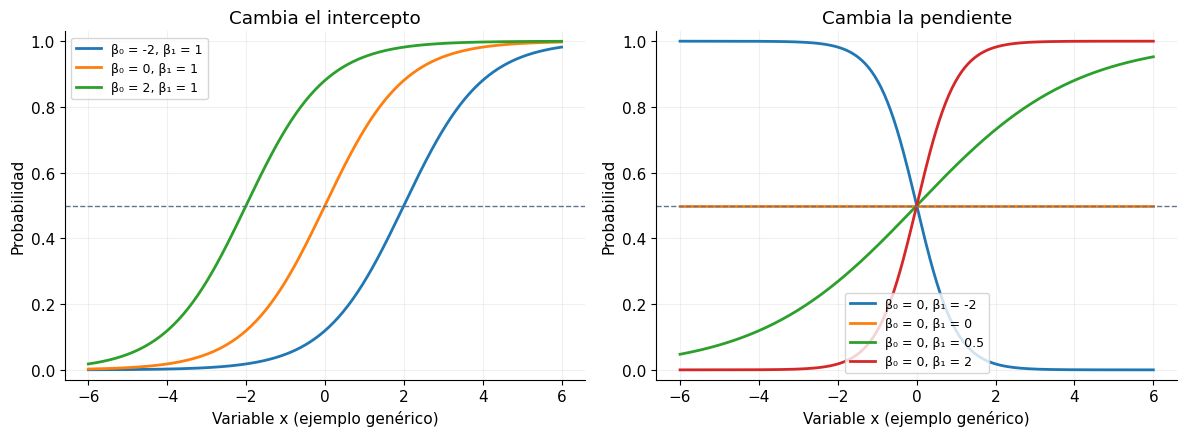

In [ ]:
x_demo = np.linspace(-6, 6, 300)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for b0 in [-2, 0, 2]:
    axes[0].plot(x_demo, sigmoide(b0 + x_demo), lw=2,
                 label=f"β₀ = {b0}, β₁ = 1")
for b1 in [-2, 0, 0.5, 2]:
    axes[1].plot(x_demo, sigmoide(b1 * x_demo), lw=2,
                 label=f"β₀ = 0, β₁ = {b1}")

for ax in axes:
    ax.axhline(0.5, color=GRIS, ls="--", lw=1)
    ax.set(xlabel="Variable x (ejemplo genérico)", ylabel="Probabilidad",
           ylim=(-0.03, 1.03))
    ax.legend(fontsize=9)
axes[0].set_title("Cambia el intercepto")
axes[1].set_title("Cambia la pendiente")
plt.tight_layout()
plt.show()


**Lectura del experimento:**

- Al aumentar el intercepto, aumenta la probabilidad para un mismo valor de $x$.
- Una pendiente positiva produce una curva creciente; una negativa, decreciente.
- Una mayor magnitud de la pendiente produce una transición más pronunciada.
- Si la pendiente es cero, la probabilidad es constante.

Con $\beta_1\ne 0$, el punto donde $p=0,5$ cumple $x=-\beta_0/\beta_1$. En el panel derecho todas las curvas pasan por $(0;\,0,5)$ porque fijamos $\beta_0=0$.


### De la fórmula a scikit-learn

Recuperemos los coeficientes aprendidos y reconstruyamos el cálculo para varios estudiantes.

- `intercept_`: intercepto.
- `coef_`: coeficientes.
- `decision_function()`: puntaje lineal.
- `predict_proba()`: probabilidades de las clases.
- `predict()`: clase asignada.


In [ ]:
b0 = logistica.intercept_[0]
b1 = logistica.coef_[0, 0]
ejemplos = pd.DataFrame({"horas": [1, 3, 5, 7, 9]})

z_manual = b0 + b1 * ejemplos["horas"]
p_manual = sigmoide(z_manual)
p_sklearn = logistica.predict_proba(ejemplos)[:, col_positiva]

print(f"Modelo ajustado: z = {b0:.3f} + {b1:.3f} × horas")
display(ejemplos.assign(
    puntaje=z_manual,
    probabilidad_manual=p_manual,
    probabilidad_sklearn=p_sklearn,
    clase=logistica.predict(ejemplos)
).round(4))

np.testing.assert_allclose(z_manual, logistica.decision_function(ejemplos))
np.testing.assert_allclose(p_manual, p_sklearn)
print("La fórmula manual y scikit-learn coinciden.")


Modelo ajustado: z = -4.652 + 0.914 × horas


,horas,puntaje,probabilidad_manual,probabilidad_sklearn,clase
0,1,-3.7384,0.0232,0.0232,0
1,3,-1.9112,0.1288,0.1288,0
2,5,-0.0839,0.4790,0.4790,0
3,7,1.7433,0.8511,0.8511,1
4,9,3.5705,0.9726,0.9726,1


La fórmula manual y scikit-learn coinciden.


### ¿Qué significa el coeficiente?

Un $\beta_1$ positivo indica que, en el modelo, más horas se asocian con una mayor probabilidad de aprobar. **No significa que cada hora sume $\beta_1$ puntos de probabilidad.**

La relación que sí es lineal es:

$$\log\left(\frac{p}{1-p}\right)=\beta_0+\beta_1x$$

El cociente $p/(1-p)$ se llama *odds*: compara la probabilidad de aprobar con la de no aprobar. Por ejemplo, si $p=0,8$, las odds son $0,8/0,2=4$.
![odds](./Clases_ML/Odds.md)


Al aumentar $x$ una unidad, las odds se multiplican por $e^{\beta_1}$. La probabilidad cambia en distinta magnitud según el punto de partida.


In [ ]:
horas_iniciales = np.array([1, 4, 8])
p_antes = sigmoide(b0 + b1 * horas_iniciales)
p_despues = sigmoide(b0 + b1 * (horas_iniciales + 1))
odds_antes = p_antes / (1 - p_antes)
odds_despues = p_despues / (1 - p_despues)

display(pd.DataFrame({
    "Horas iniciales": horas_iniciales,
    "p antes": p_antes,
    "p con una hora más": p_despues,
    "Cambio en puntos porcentuales": 100 * (p_despues - p_antes),
    "Multiplicador de odds": odds_despues / odds_antes
}).round(3))
print(f"exp(β₁) = {np.exp(b1):.3f}")


,Horas iniciales,p antes,p con una hora más,Cambio en puntos porcentuales,Multiplicador de odds
0,1,0.023,0.056,3.276,2.493
1,4,0.269,0.479,20.960,2.493
2,8,0.934,0.973,3.819,2.493


exp(β₁) = 2.493


**Conclusión.** La misma hora adicional produce cambios diferentes en probabilidad, pero el multiplicador de odds permanece constante en este modelo. Esta es una asociación del modelo: el ajuste por sí solo no demuestra causalidad.


## 4. Probabilidad y clasificación: ¿qué cambia al mover el umbral?

Para decidir una clase elegimos un umbral. En este cuaderno usaremos la regla:

**Asignar 1 si la probabilidad supera el umbral; asignar 0 en caso contrario.**

En el caso binario, `predict()` utiliza el corte equivalente a 0,5. Para decidir con otro umbral, trabajamos con `predict_proba()`.

**Pregunta:** un estudiante tiene probabilidad 0,35. ¿Qué clase recibe con un umbral de 0,2? ¿Y con uno de 0,5? ¿Cambió su probabilidad?


,horas,Resultado real,Probabilidad,Clase con umbral 0.2,Clase con umbral 0.5,Clase con umbral 0.8
204,0.139,0,0.011,0,0,0
85,0.900,1,0.021,0,0,0
130,1.706,0,0.043,0,0,0
266,2.847,0,0.114,0,0,0
32,3.258,0,0.158,0,0,0
56,4.589,1,0.387,1,0,0
273,5.911,0,0.679,1,1,0
155,6.722,1,0.816,1,1,1
200,7.774,1,0.921,1,1,1
41,8.327,0,0.951,1,1,1


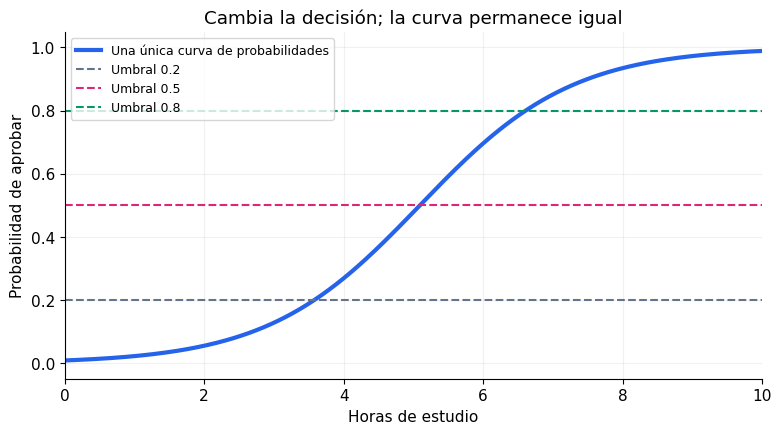

In [ ]:
p_test = logistica.predict_proba(X_test)[:, col_positiva]
umbrales = [0.2, 0.5, 0.8]

tabla_decisiones = X_test.copy()
tabla_decisiones["Resultado real"] = y_test
tabla_decisiones["Probabilidad"] = p_test
for umbral in umbrales:
    tabla_decisiones[f"Clase con umbral {umbral}"] = (p_test > umbral).astype(int)

display(tabla_decisiones.sort_values("Probabilidad").iloc[::8].round(3))

fig, ax = plt.subplots()
ax.plot(rejilla["horas"], pred_logistica, color=AZUL, lw=3,
        label="Una única curva de probabilidades")
for umbral, color in zip(umbrales, [GRIS, ROSA, "#059669"]):
    ax.axhline(umbral, color=color, ls="--", label=f"Umbral {umbral}")
ax.set(xlabel="Horas de estudio", ylabel="Probabilidad de aprobar",
       title="Cambia la decisión; la curva permanece igual", xlim=(0, 10))
ax.legend(fontsize=9)
plt.show()


### ¿Qué errores cambian?

Como la clase 1 significa “aprobó”:

- **Falso positivo:** predecimos que aprueba, pero no aprueba.
- **Falso negativo:** predecimos que no aprueba, pero aprueba.

Al bajar el umbral clasificamos más estudiantes como positivos. Podemos detectar más aprobados, a costa de clasificar como aprobados a más estudiantes que no aprobaron.

La *accuracy* o exactitud es la proporción total de aciertos. No distingue entre los dos tipos de error.


,Umbral,Predichos como aprobados,Falsos positivos,Falsos negativos,Aciertos,Accuracy
0,0.2,57,20,5,65,0.722
1,0.5,46,12,8,70,0.778
2,0.8,36,8,14,68,0.756


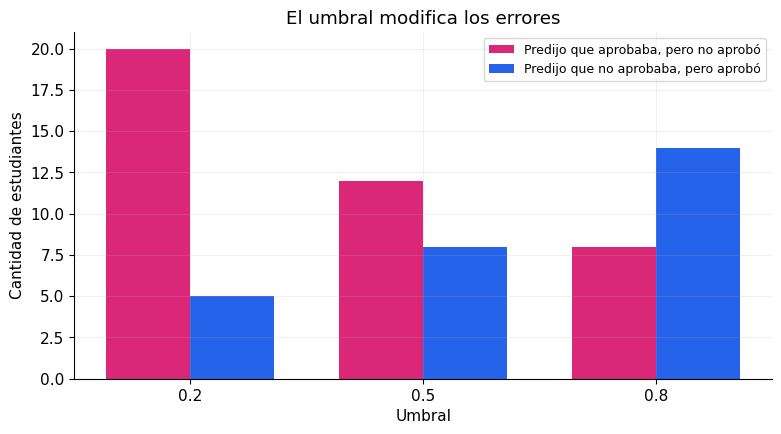

Pérdida logarítmica en prueba: 0.546
Es la misma para los tres umbrales: las probabilidades no cambiaron.


In [ ]:
resultados = []
for umbral in umbrales:
    clase = (p_test > umbral).astype(int)
    vn, fp, fn, vp = confusion_matrix(y_test, clase, labels=[0, 1]).ravel()
    resultados.append({
        "Umbral": umbral,
        "Predichos como aprobados": int(clase.sum()),
        "Falsos positivos": fp,
        "Falsos negativos": fn,
        "Aciertos": vn + vp,
        "Accuracy": accuracy_score(y_test, clase)
    })

tabla_umbrales = pd.DataFrame(resultados)
display(tabla_umbrales.round(3))

fig, ax = plt.subplots()
posiciones = np.arange(len(umbrales))
ax.bar(posiciones - 0.18, tabla_umbrales["Falsos positivos"], width=0.36,
       color=ROSA, label="Predijo que aprobaba, pero no aprobó")
ax.bar(posiciones + 0.18, tabla_umbrales["Falsos negativos"], width=0.36,
       color=AZUL, label="Predijo que no aprobaba, pero aprobó")
ax.set(xticks=posiciones, xticklabels=umbrales, xlabel="Umbral",
       ylabel="Cantidad de estudiantes", title="El umbral modifica los errores")
ax.legend(fontsize=9)
plt.show()

print(f"Pérdida logarítmica en prueba: {log_loss(y_test, p_test):.3f}")
print("Es la misma para los tres umbrales: las probabilidades no cambiaron.")


**Conclusión.** No existe un umbral que sea el mejor para cualquier situación. La elección depende del uso del modelo y del costo de cada error.

Por ejemplo, si una predicción de “no aprueba” activa una tutoría, un falso positivo puede dejar sin apoyo a alguien que lo necesitaba. El significado de los errores depende de la acción que tomemos.

Esta comparación ilustra umbrales prefijados. Para elegir uno para uso real se necesita validación separada; después se evalúa la decisión final en prueba.


## 5. Ideas para llevarse

1. **La respuesta observada es una categoría; el modelo estima una probabilidad.**
2. **La combinación lineal produce un puntaje; la sigmoide lo transforma.**
3. **El ajuste busca coeficientes que expliquen los resultados observados mediante sus probabilidades.**
4. **Un coeficiente no es un cambio fijo en puntos de probabilidad.**
5. **El umbral transforma probabilidades en decisiones y modifica los errores.**
6. **La regresión logística es lineal en el logit; con dos variables originales, su frontera es una recta.**

$$\text{Variables}\;\longrightarrow\;z\;\longrightarrow\;p\;\longrightarrow\;\text{decisión según el umbral}$$



### Referencias

- [Regresión logística: guía oficial de scikit-learn](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression).
- [LogisticRegression: parámetros, coeficientes y métodos](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).
- [Probabilidades y umbrales de clasificación](https://scikit-learn.org/stable/modules/classification_threshold.html).
- [Pérdida logarítmica](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.log_loss.html).

Los datos, explicaciones y experimentos de este cuaderno se prepararon como material didáctico. Las referencias documentan la implementación utilizada.
